In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the Customer Data
# Note: If your notebook is in the same directory as the file, use 'q2_customers.csv'
df_q2 = pd.read_csv('../data/q2_customers.csv')
features = ['age', 'annual_spend', 'visits_per_month', 'basket_size', 'days_since_last_visit', 'num_categories_purchased']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_q2[features])

**Why Feature Scaling is Mandatory:**

Algorithms are context-blind. Because K-Means relies on **Euclidean distance**, it treats every unit as equal. Without scaling, a feature like `annual_spend` (ranging in the thousands) would mathematically overwhelm a feature like `visits_per_month` (ranging in single digits). 

Scaling via **StandardScaler** transforms the data so that each feature has a mean of 0 and a standard deviation of 1. This "levels the playing field," forcing the machine to treat a significant change in spending behavior and a significant change in visit frequency with equal importance. Without this step, the clusters would be dictated entirely by the features with the largest raw numbers.

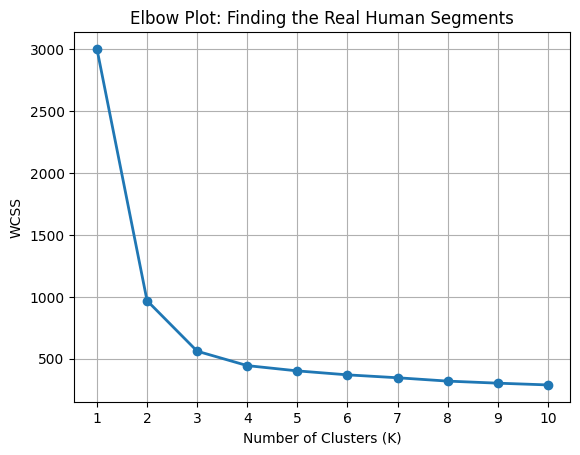

In [2]:
# 2. Choosing K
wcss = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in range(1, 11)]

plt.plot(range(1, 11), wcss, marker='o', linewidth=2)
plt.title('Elbow Plot: Finding the Real Human Segments')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Choosing the Optimal K (Elbow Method):**

The Elbow Plot demonstrates a sharp, definitive break at **K=3**.

* **The Elbow Point:** The Within-Cluster Sum of Squares (WCSS) drops steeply until K=3, after which the rate of decrease plateaus. This identifies K=3 as the mathematical "sweet spot" for balancing model complexity with cluster cohesion.
* **Avoidance of Over-segmentation:** Extending the model to K=4 or beyond offers diminishing returns and would lead to "over-fitting" our customer segments. 
* **Business Actionability:** By sticking to 3 clusters, we create high-impact, distinct segments (The Frequent Youth, The Lapsed Premiums, and The Steady Middle) that a marketing department can actually target with specific strategies, rather than diluted micro-groups.


In [3]:
# 3. Running K-Means
k_opt = 3 
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_q2['cluster'] = km.fit_predict(X_scaled)

# Reverting back to human numbers to actually understand the centroids
centroids = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=features)
centroids.index = [f'Cluster {i}' for i in range(k_opt)]
display(centroids.round(2))

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.68,14847.37,14.34,558.97,9.08,2.11
Cluster 1,56.77,89413.33,2.53,5530.55,105.36,7.52
Cluster 2,40.39,43340.73,8.19,2021.68,35.19,4.42


**The Human Interpretation of the Clusters:**
* **Cluster 0 (The Frequent Youth):** Average age ~25. They spend the least ($14.8k) but visit almost 14 times a month. They are high-frequency, low-margin convenience shoppers.
* **Cluster 1 (The Lapsed Premiums):** Older demographic (~57). They have massive historical spend ($89k) and huge basket sizes, but haven't visited in over 100 days. They are "at-risk" high-value customers.
* **Cluster 2 (The Steady Middle):** Age ~40. Moderate spend ($43k) and moderate frequency. This is the loyal "backbone" of the customer base.

In [4]:
# 4. Dimensionality Reduction (PCA)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
print("\nFeature Loadings:")
display(loadings)

Explained Variance Ratio:
PC1: 0.8356 (83.56%)
PC2: 0.0557 (5.57%)

Feature Loadings:


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


**What the PCA Math Actually Means:**
* **PC1 (83.6%):** This is the "Customer Lifetime Value" axis. Because `annual_spend`, `basket_size`, and `num_categories` all have high positive loadings (~0.41), this dimension separates big spenders from small spenders.
* **PC2 (5.6%):** This is the "Recency" axis. The massive loading for `days_since_last_visit` (0.91) means this dimension almost exclusively tracks how long it has been since the customer last walked through the door.

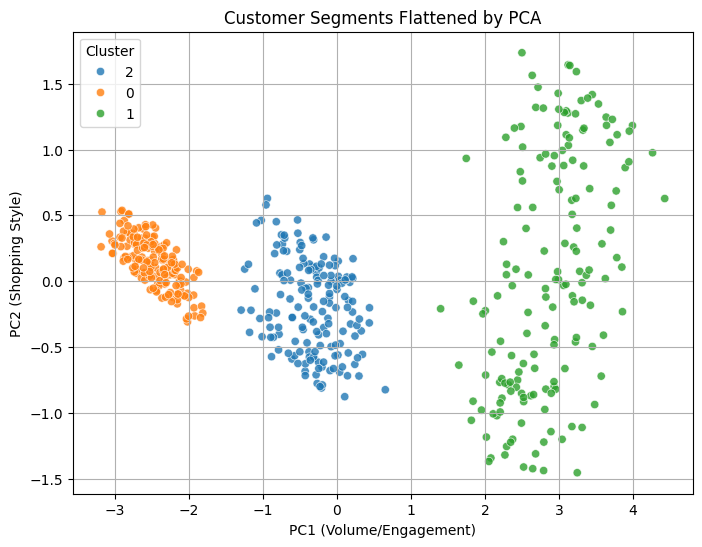

In [5]:
# 5. Visualizing the Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=pcs[:,0], y=pcs[:,1], hue=df_q2['cluster'].astype(str), palette='tab10', alpha=0.8)
plt.title('Customer Segments Flattened by PCA')
plt.xlabel('PC1 (Volume/Engagement)')
plt.ylabel('PC2 (Shopping Style)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()